In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [2]:
import numpy as np
import pandas as pd
df=pd.read_csv("./GIT/malaria_esp_index.csv", sep=",",index_col=0)
df.index = pd.to_datetime(df.index)
df

,NumValue,TG,HU,RR,FG
2008-01-01,17.0,90.860215,74.630824,13.340502,28.311828
2008-02-01,12.0,102.823755,72.486590,15.088123,30.697318
2008-03-01,13.0,110.168459,61.075269,13.365114,43.698925
2008-04-01,12.0,137.522222,62.040741,26.822222,37.881481
2008-05-01,16.0,159.813620,68.611708,41.942652,32.086022
...,...,...,...,...,...
2023-08-01,109.0,256.928315,48.641577,6.689101,32.767025
2023-09-01,123.0,214.903704,66.092593,35.758303,27.278042
2023-10-01,130.0,186.992832,65.752688,31.425568,31.433692
2023-11-01,73.0,132.651852,71.700000,24.961184,35.000000


In [3]:
df.corr(method='pearson')

,NumValue,TG,HU,RR,FG
NumValue,1.000000,0.467724,-0.233247,-0.136402,-0.457260
TG,0.467724,1.000000,-0.812346,-0.522575,-0.425230
HU,-0.233247,-0.812346,1.000000,0.716796,0.133839
RR,-0.136402,-0.522575,0.716796,1.000000,0.339987
FG,-0.457260,-0.425230,0.133839,0.339987,1.000000


### Cálculo de la ventana deslizante

In [4]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [5]:
df_inf=one_step_forecast(df.iloc[:,0],3) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],3).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp'},axis=1) #ventana deslizante de temperatura

In [6]:
df=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_inf.iloc[:,2],df_temp.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2]],axis=1)
df

,y,x_1,x_1_temp,x_2,x_2_temp,x_3,x_3_temp
2008-01-01,12.0,17.0,90.860215,12.0,102.823755,13.0,110.168459
2008-02-01,16.0,12.0,102.823755,13.0,110.168459,12.0,137.522222
2008-03-01,33.0,13.0,110.168459,12.0,137.522222,16.0,159.813620
2008-04-01,25.0,12.0,137.522222,16.0,159.813620,33.0,202.959259
2008-05-01,35.0,16.0,159.813620,33.0,202.959259,25.0,231.810036
...,...,...,...,...,...,...,...
2023-05-01,109.0,47.0,175.333333,54.0,224.259259,71.0,252.641577
2023-06-01,123.0,54.0,224.259259,71.0,252.641577,109.0,256.928315
2023-07-01,130.0,71.0,252.641577,109.0,256.928315,123.0,214.903704
2023-08-01,73.0,109.0,256.928315,123.0,214.903704,130.0,186.992832


### Normalización y separación en test y train 

In [7]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

In [8]:
train,test=split_data(df)

In [9]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm=pd.DataFrame(norm.fit_transform(train),index=train.index,columns=train.columns)
test_norm=pd.DataFrame(norm.transform(test),index=test.index,columns=test.columns)

In [10]:
xtrainN=train_norm.iloc[:,1:]
xtestN=test_norm.iloc[:,1:]
ytrainN=train_norm.iloc[:,0]
ytestN=test_norm.iloc[:,0]

### Regresión lineal

In [11]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(xtrainN,ytrainN)
ypred=regr.predict(xtestN)
Y_rl=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rl['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rl

,ytest,ypred
2022-04-01,0.568493,0.411026
2022-05-01,0.664384,0.631264
2022-06-01,0.589041,0.670141
2022-07-01,0.684932,0.510213
2022-08-01,0.438356,0.578586
2022-09-01,0.280822,0.318432
2022-10-01,0.287671,0.181169
2022-11-01,0.226027,0.188648
2022-12-01,0.239726,0.194807
2023-01-01,0.239726,0.282299


In [12]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(ytestN, ypred)
r2=r2_score(ytestN, ypred)
print(mse)
print(r2)

0.013516146249443748
0.6891735969218992


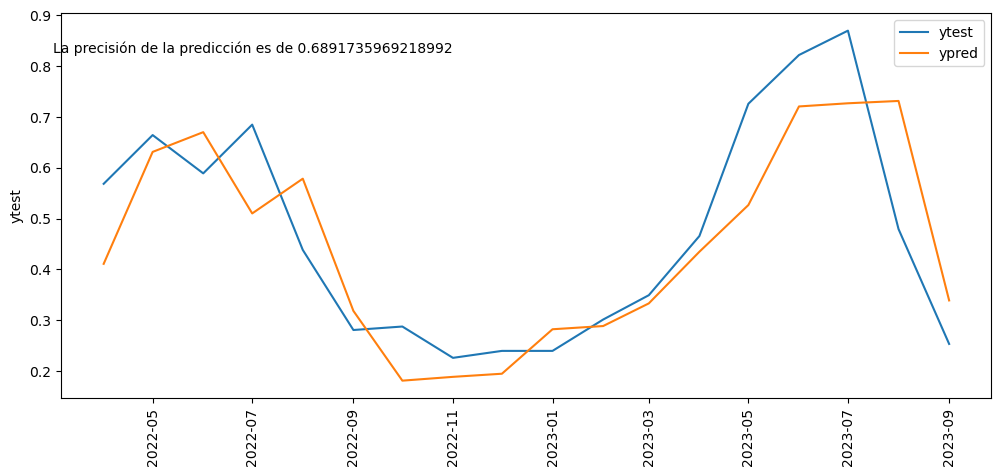

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ytest,label='ytest')
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_rl.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rl.ytest, Y_rl.ypred)), fontsize=10)
plt.show()

### KNNeighbors

In [14]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(xtrainN,ytrainN)
    ypred=knn.predict(xtestN.values.astype(np.float32))
    v.append(r2_score(ytestN, ypred))

v

[0.3677964577901647,
 0.5104737930414458,
 0.7192270936764329,
 0.7964090922712698,
 0.8497959183673469,
 0.8307594207531277,
 0.8761737186108823,
 0.8331572717192605,
 0.8048724901392548,
 0.7972021936527915,
 0.7900193899965056,
 0.7646472441154633,
 0.7802318383235265,
 0.7998151161930205]

In [15]:
knn=KNeighborsRegressor(n_neighbors=8)
knn.fit(xtrainN,ytrainN)

KNeighborsRegressor(n_neighbors=8)

In [16]:
ypred_knn=knn.predict(xtestN.values.astype(np.float32))
Y_knn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_knn['ypred']=pd.DataFrame(ypred_knn,index=ytestN.index)
Y_knn

,ytest,ypred
2022-04-01,0.568493,0.405822
2022-05-01,0.664384,0.642979
2022-06-01,0.589041,0.743151
2022-07-01,0.684932,0.576199
2022-08-01,0.438356,0.446918
2022-09-01,0.280822,0.274829
2022-10-01,0.287671,0.261986
2022-11-01,0.226027,0.141267
2022-12-01,0.239726,0.141267
2023-01-01,0.239726,0.215753


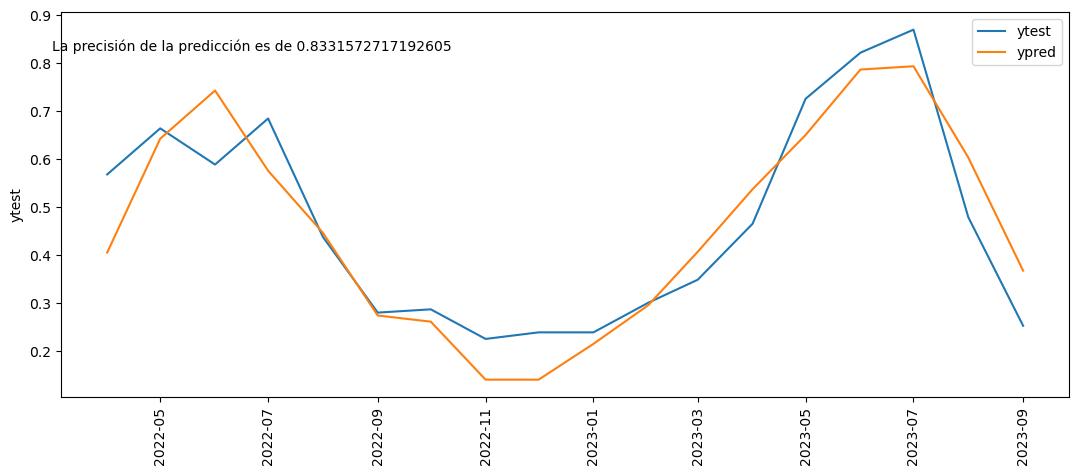

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ytest,label='ytest')
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_knn.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_knn.ytest, Y_knn.ypred)), fontsize=10)
plt.show()

### Random Forest 

In [18]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [19]:
rf=RandomForestRegressor(random_state=0)
rf.fit(xtrainN,ytrainN)

RandomForestRegressor(random_state=0)

In [20]:
ypred=rf.predict(xtestN.values.astype(np.float32))
Y_rf=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rf['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rf

,ytest,ypred
2022-04-01,0.568493,0.422877
2022-05-01,0.664384,0.631849
2022-06-01,0.589041,0.892603
2022-07-01,0.684932,0.637603
2022-08-01,0.438356,0.565274
2022-09-01,0.280822,0.312945
2022-10-01,0.287671,0.288767
2022-11-01,0.226027,0.198356
2022-12-01,0.239726,0.199041
2023-01-01,0.239726,0.257329


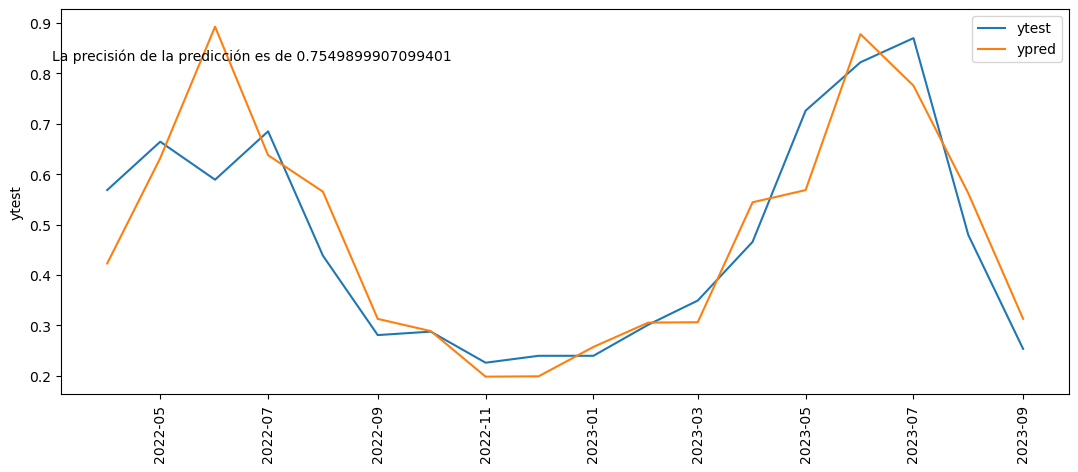

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ytest,label='ytest')
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_rf.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf.ytest, Y_rf.ypred)), fontsize=10)
plt.show()

### Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(random_state=0)
gbr.fit(xtrainN,ytrainN)
ypred_gbr=gbr.predict(xtestN.values.astype(np.float32))
Y_gbr=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_gbr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN.index)
Y_gbr

,ytest,ypred
2022-04-01,0.568493,0.451742
2022-05-01,0.664384,0.598469
2022-06-01,0.589041,0.947146
2022-07-01,0.684932,0.532136
2022-08-01,0.438356,0.604129
2022-09-01,0.280822,0.288709
2022-10-01,0.287671,0.296110
2022-11-01,0.226027,0.163954
2022-12-01,0.239726,0.217469
2023-01-01,0.239726,0.281148


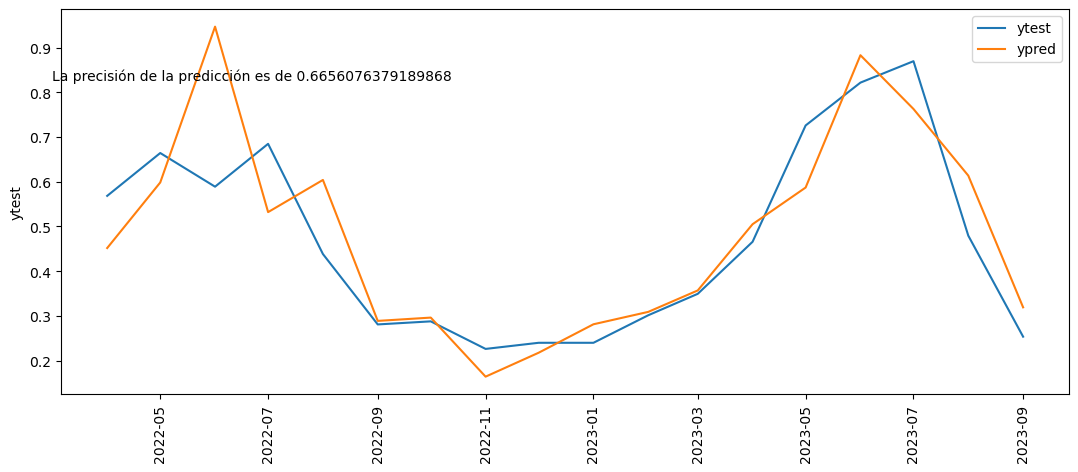

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ytest,label='ytest')
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_gbr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr.ytest, Y_gbr.ypred)), fontsize=10)
plt.show()

### Validación

In [24]:
xtrainN,xvalN=split_data(xtrainN)
ytrainN,yvalN=split_data(ytrainN)

### RNA

In [25]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [26]:
Y_rna=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rna=Sequential()
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(1))
    rna.compile(optimizer='adam',loss='mean_squared_error')
    rna.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna=rna.predict(xtestN)
    Y_rna['ypred_'+str(i)]=pd.DataFrame(ypred_rna,index=ytestN.index)
    
Y_rna

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0870 - val_loss: 0.0570
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0762 - val_loss: 0.0471
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0648 - val_loss: 0.0363
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0514 - val_loss: 0.0255
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0379 - val_loss: 0.0168
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0282 - val_loss: 0.0139
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0250 - val_loss: 0.0186
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0318 - val_loss: 0.0229
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0371 - val_loss: 0.0208
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0333 - val_loss: 0.0170
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0308 - val_loss: 0.0145
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0277 - val_loss

Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0078 - val_loss: 0.0033
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073 - val_loss: 0.0031
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - val_loss: 0.0034
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0078 - val_loss: 0.0033
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0069 - val_loss: 0.0031
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0040
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - val_loss: 0.0032
Epoch 148/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0081 - val_loss: 0.0033
Epoch 149/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074 - val_loss: 0.0041
Epoch 150/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0028
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0029
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0028
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0063 - val_loss: 0.0028
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0031
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0028
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078 - val_loss: 0.0029
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073 - val_loss: 0.0037
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0076 - val_loss: 0.0031
Epoch 284/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0067 - val_loss: 0.0031
Epoch 285/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0032
Epoch 286/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0064 - val_loss: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0029
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0027
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0030
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - val_loss: 0.0028
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060 - val_loss: 0.0028
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0074 - val_loss: 0.0029
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0068 - val_loss: 0.0028
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058 - val_loss: 0.0029
Epoch 419/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0028
Epoch 420/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - val_loss: 0.0029
Epoch 421/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - val_loss: 0.0031
Epoch 422/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054 - val_l

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0149 - val_loss: 0.0032
Epoch 48/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0135 - val_loss: 0.0032
Epoch 49/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143 - val_loss: 0.0031
Epoch 50/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114 - val_loss: 0.0030
Epoch 51/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0135 - val_loss: 0.0031
Epoch 52/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - val_loss: 0.0030
Epoch 53/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0130 - val_loss: 0.0029
Epoch 54/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0124 - val_loss: 0.0028
Epoch 55/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0123 - val_loss: 0.0028
Epoch 56/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - val_loss: 0.0027
Epoch 57/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0108 - val_loss: 0.0027
Epoch 58/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0125 - val_loss: 0.0026

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0874 - val_loss: 0.0577
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0775 - val_loss: 0.0483
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0661 - val_loss: 0.0379
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0539 - val_loss: 0.0272
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0402 - val_loss: 0.0178
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0296 - val_loss: 0.0126
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0220 - val_loss: 0.0147
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0266 - val_loss: 0.0203
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0321 - val_loss: 0.0216
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0372 - val_loss: 0.0179
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0341 - val_loss: 0.0143
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 0.0030
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 - val_loss: 0.0029
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0030
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0034
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0034
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0064 - val_loss: 0.0035
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0033
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0086 - val_loss: 0.0033
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078 - val_loss: 0.0039
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - val_loss: 0.0039
Epoch 148/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0033
Epoch 149/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0081 - val_loss: 0.0039
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0069 - val_loss: 0.0035
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0036
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0037
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0033
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - val_loss: 0.0033
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - val_loss: 0.0040
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0077 - val_loss: 0.0035
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0070 - val_loss: 0.0033
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0038
Epoch 284/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - val_loss: 0.0037
Epoch 285/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0074 - val_loss: 0.0036
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0076 - val_loss: 0.0036
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - val_loss: 0.0039
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0037
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073 - val_loss: 0.0036
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0035
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0070 - val_loss: 0.0035
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064 - val_loss: 0.0034
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 419/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0037
Epoch 420/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088 - val_loss: 0.0044
Epoch 421/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - val_loss

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-04-01,0.568493,0.467562,0.503705,0.475411,0.516474
2022-05-01,0.664384,0.734346,0.790353,0.709106,0.763671
2022-06-01,0.589041,0.799601,0.814790,0.749988,0.789893
2022-07-01,0.684932,0.431035,0.426402,0.373723,0.422324
2022-08-01,0.438356,0.418117,0.425775,0.383095,0.415297
2022-09-01,0.280822,0.308479,0.301080,0.284822,0.307855
2022-10-01,0.287671,0.235063,0.229277,0.224668,0.229992
2022-11-01,0.226027,0.181754,0.187110,0.196819,0.188528
2022-12-01,0.239726,0.165909,0.176901,0.191098,0.180701
2023-01-01,0.239726,0.266604,0.259511,0.235872,0.257427


In [27]:
v=[]
for i in range(4):
    v.append(r2_score(Y_rna.iloc[:,0], Y_rna.iloc[:,i+1]))

v

[0.7556709805936195,
 0.7383891133387865,
 0.7181142960163369,
 0.7561921895885707]

### RNN

In [28]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import SimpleRNN, Dropout, Dense

In [29]:
Y_rnn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn1=Sequential()
    rnn1.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn1.add(Dropout(0.1))
    rnn1.add(Dense(1))
    rnn1.compile(optimizer='adam',loss='mean_squared_error')
    rnn1.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn=rnn1.predict(xtestN)
    Y_rnn['ypred_'+str(i)]=pd.DataFrame(ypred_rnn,index=ytestN.index)
    
Y_rnn

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0444 - val_loss: 0.0179
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0282 - val_loss: 0.0070
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - val_loss: 0.0033
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0164 - val_loss: 0.0041
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0188 - val_loss: 0.0057
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0221 - val_loss: 0.0060
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0210 - val_loss: 0.0050
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0188 - val_loss: 0.0041
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0143 - val_loss: 0.0036
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0149 - val_loss: 0.0034
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - val_loss: 0.0035
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0111 - val_loss: 0.

Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 0.0044
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - val_loss: 0.0044
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059 - val_loss: 0.0043
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0064 - val_loss: 0.0042
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0043
Epoch 148/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059 - val_loss: 0.0047
Epoch 149/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - val_loss: 0.0046
Epoch 150/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 

Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0047
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 0.0051
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0051
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - val_loss: 0.0049
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0049
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 284/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 0.0046
Epoch 285/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 286/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0048
Epoch 287/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0040 - val_loss: 0.0060
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - val_loss: 0.0052
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0033 - val_loss: 0.0050
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - val_loss: 0.0056
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - val_loss: 0.0061
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0061
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0032 - val_loss: 0.0052
Epoch 419/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0038 - val_loss: 0.0050
Epoch 420/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0056
Epoch 421/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0031 - val_loss: 0.0061
Epoch 422/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035 - val_loss: 0.0058
Epoch 423/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_l

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0087 - val_loss: 0.0028
Epoch 43/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0092 - val_loss: 0.0029
Epoch 44/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0113 - val_loss: 0.0028
Epoch 45/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0103 - val_loss: 0.0028
Epoch 46/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 - val_loss: 0.0027
Epoch 47/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0094 - val_loss: 0.0027
Epoch 48/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082 - val_loss: 0.0026
Epoch 49/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089 - val_loss: 0.0027
Epoch 50/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0083 - val_loss: 0.0027
Epoch 51/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082 - val_loss: 0.0028
Epoch 52/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0088 - val_loss: 0.0028
Epoch 53/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0086 - val_loss: 0.0029


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 61/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0033
Epoch 62/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0035
Epoch 63/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0076 - val_loss: 0.0036
Epoch 64/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0037
Epoch 65/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 66/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0034
Epoch 67/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - val_loss: 0.0035
Epoch 68/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0071 - val_loss: 0.0037
Epoch 69/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 0.0034
Epoch 70/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0075 - val_loss: 0.0034
Epoch 71/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0038
Ep

Epoch 129/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0043
Epoch 130/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - val_loss: 0.0040
Epoch 131/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0041
Epoch 132/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 133/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 134/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 0.0038
Epoch 135/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0045 - val_loss: 0.0047
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0038 - val_loss: 0.0047
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - val_loss: 0.0045
Epoch 266/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 0.0049
Epoch 267/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 268/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 - val_loss: 0.0045
Epoch 269/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 270/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - val_loss: 0.0046
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - val_loss: 0.0044
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - val_loss: 0.0046
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - val_lo

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 0.0053
Epoch 402/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0055
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - val_loss: 0.0057
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0048
Epoch 407/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - val_loss: 0.0055
Epoch 408/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - val_loss: 0.0054
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 0.0049
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - val_loss: 0.0048
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0052
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - val_l

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-04-01,0.568493,0.512658,0.475307,0.465429,0.459986
2022-05-01,0.664384,0.744482,0.665253,0.743993,0.719049
2022-06-01,0.589041,0.797621,0.881050,0.825657,0.869856
2022-07-01,0.684932,0.396100,0.476057,0.365165,0.439147
2022-08-01,0.438356,0.480718,0.412736,0.407669,0.389138
2022-09-01,0.280822,0.316912,0.276453,0.307550,0.287848
2022-10-01,0.287671,0.348824,0.256656,0.312099,0.302662
2022-11-01,0.226027,0.159494,0.171266,0.147210,0.146719
2022-12-01,0.239726,0.165672,0.149003,0.174048,0.160709
2023-01-01,0.239726,0.259012,0.249787,0.282162,0.250037


In [30]:
w=[]
for i in range(4):
    w.append(r2_score(Y_rnn.iloc[:,0], Y_rnn.iloc[:,i+1]))

w

[0.7578124900977429,
 0.7835536180668791,
 0.6648861658976255,
 0.7592695446164885]

### LSTM

In [31]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, LSTM, Dropout

In [32]:
Y_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    lstm = Sequential()
    lstm.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm.add(Dropout(0.1))
    lstm.add(Dense(1))
    lstm.compile(optimizer='adam', loss='mean_squared_error')
    lstm.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm=lstm.predict(xtestN) 
    Y_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_lstm,index=ytestN.index)

Y_lstm

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0680 - val_loss: 0.0388
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0517 - val_loss: 0.0267
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0390 - val_loss: 0.0172
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0273 - val_loss: 0.0107
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0209 - val_loss: 0.0082
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200 - val_loss: 0.0092
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0228 - val_loss: 0.0111
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0242 - val_loss: 0.0112
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0252 - val_loss: 0.0096
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0222 - val_loss: 0.0079
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0212 - val_loss: 0.0068
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0196 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0092 - val_loss: 0.0034
Epoch 71/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0094 - val_loss: 0.0044
Epoch 72/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0102 - val_loss: 0.0034
Epoch 73/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0095 - val_loss: 0.0032
Epoch 74/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080 - val_loss: 0.0041
Epoch 75/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0102 - val_loss: 0.0038
Epoch 76/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - val_loss: 0.0035
Epoch 77/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0087 - val_loss: 0.0042
Epoch 78/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0081 - val_loss: 0.0039
Epoch 79/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - val_loss: 0.0036
Epoch 80/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - val_loss: 0.0039
Epoch 81/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0080 - val_loss: 0.0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - val_loss: 0.0037
Epoch 207/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - val_loss: 0.0036
Epoch 208/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0037
Epoch 209/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0038
Epoch 210/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 211/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - val_loss: 0.0038
Epoch 212/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - val_loss: 0.0036
Epoch 213/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - val_loss: 0.0035
Epoch 214/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0035
Epoch 215/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0055 - val_loss: 0.0036
Epoch 216/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0055 - val_loss: 0.0037
Epoch 217/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0056 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 343/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 344/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 345/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0037
Epoch 346/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 347/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 348/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 349/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - val_loss: 0.0037
Epoch 350/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - val_loss: 0.0041
Epoch 351/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 352/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 353/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - va

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 479/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 480/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 481/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 482/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 483/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 484/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 485/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047 - val_loss: 0.0041
Epoch 486/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 487/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 488/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 489/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0046 -

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 0.0038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0676 - val_loss: 0.0373
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0499 - val_loss: 0.0254
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0368 - val_loss: 0.0164
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0270 - val_loss: 0.0102
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0206 - val_loss: 0.0076
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0187 - val_loss: 0.0081
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0190 - val_loss: 0.0099
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0221 - val_loss: 0.0104
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0251 - val_loss: 0.0092
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0221 - val_loss: 0.0077
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/st

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - val_loss: 0.0037
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064 - val_loss: 0.0037
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0062 - val_loss: 0.0036
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0036
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - val_loss: 0.0034
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0057 - val_loss: 0.0035
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0035
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0057 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 0.0034
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053 - val_loss: 0.0036
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052 - val_loss: 0.0036
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 0.0035
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049 - val_loss: 0.0035
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 0.0036
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0054 - val_loss: 0.0041
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 0.0042
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 419/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0044 -

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-04-01,0.568493,0.458897,0.448703,0.438928,0.454266
2022-05-01,0.664384,0.733446,0.666948,0.683273,0.709189
2022-06-01,0.589041,0.821450,0.820182,0.862716,0.808494
2022-07-01,0.684932,0.444327,0.483551,0.450526,0.451121
2022-08-01,0.438356,0.416127,0.386257,0.381641,0.407953
2022-09-01,0.280822,0.383619,0.384310,0.364234,0.383635
2022-10-01,0.287671,0.246622,0.221585,0.235638,0.233884
2022-11-01,0.226027,0.192892,0.203968,0.207478,0.186727
2022-12-01,0.239726,0.147634,0.169043,0.169378,0.155370
2023-01-01,0.239726,0.158913,0.168585,0.181774,0.170076


In [33]:
u=[]
for i in range(4):
    u.append(r2_score(Y_lstm.iloc[:,0], Y_lstm.iloc[:,i+1]))

u

[0.749437590388853, 0.7708486485670222, 0.7393156639335607, 0.7636717535036313]

### GRU

In [34]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, GRU, Dropout

In [35]:
Y_gru=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    gru = Sequential()
    gru.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru.add(Dropout(0.1))
    gru.add(Dense(1))
    gru.compile(optimizer='adam', loss='mean_squared_error')
    gru.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN)) 
    ypred_gru=gru.predict(xtestN)
    Y_gru['ypred_'+str(i)]=pd.DataFrame(ypred_gru,index=ytestN.index)

Y_gru

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0903 - val_loss: 0.0438
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0550 - val_loss: 0.0233
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0344 - val_loss: 0.0122
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0216 - val_loss: 0.0092
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0193 - val_loss: 0.0112
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0228 - val_loss: 0.0139
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0282 - val_loss: 0.0141
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0276 - val_loss: 0.0122
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0260 - val_loss: 0.0096
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0231 - val_loss: 0.0074
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0204 - val_loss: 0.0059
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - val_l

Epoch 70/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - val_loss: 0.0033
Epoch 71/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - val_loss: 0.0033
Epoch 72/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - val_loss: 0.0035
Epoch 73/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105 - val_loss: 0.0033
Epoch 74/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0096 - val_loss: 0.0032
Epoch 75/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0035
Epoch 76/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0103 - val_loss: 0.0036
Epoch 77/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095 - val_loss: 0.0033
Epoch 78/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0086 - val_loss: 0.0035
Epoch 79/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0084 - val_loss: 0.0037
Epoch 80/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093 - val_loss: 0.0033
Epoch 81/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0092 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059 - val_loss: 0.0036
Epoch 207/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - val_loss: 0.0038
Epoch 208/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063 - val_loss: 0.0040
Epoch 209/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0039
Epoch 210/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 211/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0038
Epoch 212/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0036
Epoch 213/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 214/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0036
Epoch 215/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0037
Epoch 216/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - val_loss: 0.0038
Epoch 217/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0062 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 343/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059 - val_loss: 0.0035
Epoch 344/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 345/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050 - val_loss: 0.0036
Epoch 346/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - val_loss: 0.0036
Epoch 347/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0038
Epoch 348/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0036
Epoch 349/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0036
Epoch 350/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053 - val_loss: 0.0037
Epoch 351/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0038
Epoch 352/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 353/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0057 - val_loss: 0.0037
Epoch 479/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0036
Epoch 480/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 481/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 482/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 483/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 484/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 485/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 0.0039
Epoch 486/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 487/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 488/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 489/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 -

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - val_loss: 0.0039
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0987 - val_loss: 0.0521
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0655 - val_loss: 0.0332
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0459 - val_loss: 0.0205
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0326 - val_loss: 0.0128
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0098
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0220 - val_loss: 0.0099
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0232 - val_loss: 0.0113
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0248 - val_loss: 0.0120
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0254 - val_loss: 0.0115
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0253 - val_loss: 0.0102
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/st

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0068 - val_loss: 0.0032
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - val_loss: 0.0031
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0035
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - val_loss: 0.0031
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0031
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - val_loss: 0.0030
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - val_loss: 0.0034
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - val_loss: 0.0032
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - val_loss: 0.0031
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0033
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0033
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 0.0033
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0050 - val_loss: 0.0033
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0056 - val_loss: 0.0034
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 0.0033
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - val_loss: 0.0032
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0048 - val_loss: 0.0033
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0032
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0050 - val_loss: 0.0035
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0046 - val_loss: 0.0032
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 0.0032
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0033
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 0.0031
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - val_loss: 0.0030
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - val_loss: 0.0031
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049 - val_loss: 0.0031
Epoch 419/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - v

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-04-01,0.568493,0.437555,0.438099,0.432657,0.446696
2022-05-01,0.664384,0.728910,0.714381,0.735161,0.735156
2022-06-01,0.589041,0.830561,0.806341,0.822301,0.842211
2022-07-01,0.684932,0.450797,0.468094,0.438265,0.420569
2022-08-01,0.438356,0.415355,0.428716,0.441896,0.384587
2022-09-01,0.280822,0.376572,0.344519,0.340511,0.340052
2022-10-01,0.287671,0.235078,0.239499,0.257399,0.223801
2022-11-01,0.226027,0.206903,0.220970,0.191664,0.208185
2022-12-01,0.239726,0.162778,0.169659,0.168517,0.166591
2023-01-01,0.239726,0.182569,0.192534,0.197246,0.184062


In [36]:
y=[]
for i in range(4):
    y.append(r2_score(Y_gru.iloc[:,0], Y_gru.iloc[:,i+1]))

y

[0.7478158695767119, 0.790845705042458, 0.7673046886390558, 0.7263818854712505]

### 3-LSTM

In [37]:
Y_rnn_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn_lstm3 = Sequential()
    rnn_lstm3.add(LSTM(64, input_shape=(len(xtrainN.columns), 1),return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64,return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64))
    rnn_lstm3.add(Dense(1))
    rnn_lstm3.compile(optimizer='adam', loss='mean_squared_error')
    rnn_lstm3.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN)) 
    ypred_rnn_lstm=rnn_lstm3.predict(xtestN)
    Y_rnn_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_rnn_lstm,index=ytestN.index)

Y_rnn_lstm

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - loss: 0.0727 - val_loss: 0.0275
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0302 - val_loss: 0.0136
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0254 - val_loss: 0.0287
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0392 - val_loss: 0.0141
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0278 - val_loss: 0.0108
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0229 - val_loss: 0.0105
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0217 - val_loss: 0.0119
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0240 - val_loss: 0.0129
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0257 - val_loss: 0.0107
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0233 - val_loss: 0.0096
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0215 - val_loss: 0.0096
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0210 - val_l

Epoch 70/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0151 - val_loss: 0.0034
Epoch 71/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0147 - val_loss: 0.0035
Epoch 72/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - val_loss: 0.0042
Epoch 73/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0150 - val_loss: 0.0035
Epoch 74/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145 - val_loss: 0.0035
Epoch 75/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0037
Epoch 76/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0146 - val_loss: 0.0035
Epoch 77/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0144 - val_loss: 0.0039
Epoch 78/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0144 - val_loss: 0.0035
Epoch 79/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145 - val_loss: 0.0034
Epoch 80/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0039
Epoch 81/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0140

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0079 - val_loss: 0.0030
Epoch 207/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0078 - val_loss: 0.0028
Epoch 208/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075 - val_loss: 0.0028
Epoch 209/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0067 - val_loss: 0.0030
Epoch 210/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0080 - val_loss: 0.0029
Epoch 211/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 212/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0078 - val_loss: 0.0029
Epoch 213/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0072 - val_loss: 0.0030
Epoch 214/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0073 - val_loss: 0.0029
Epoch 215/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0082 - val_loss: 0.0030
Epoch 216/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0073 - val_loss: 0.0030
Epoch 217/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0089 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0062 - val_loss: 0.0032
Epoch 343/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0057 - val_loss: 0.0032
Epoch 344/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0056 - val_loss: 0.0034
Epoch 345/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0058 - val_loss: 0.0034
Epoch 346/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0054 - val_loss: 0.0034
Epoch 347/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 348/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0061 - val_loss: 0.0034
Epoch 349/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 350/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0055 - val_loss: 0.0035
Epoch 351/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0059 - val_loss: 0.0035
Epoch 352/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0055 - val_loss: 0.0034
Epoch 353/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0054 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 479/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 480/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 0.0034
Epoch 481/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 482/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0051 - val_loss: 0.0032
Epoch 483/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0055 - val_loss: 0.0032
Epoch 484/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0031
Epoch 485/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 486/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057 - val_loss: 0.0032
Epoch 487/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0057 - val_loss: 0.0032
Epoch 488/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 489/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0053 -

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 0.0027
Epoch 500/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - val_loss: 0.0027
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0721 - val_loss: 0.0263
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0285 - val_loss: 0.0144
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0265 - val_loss: 0.0279
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0391 - val_loss: 0.0137
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0272 - val_loss: 0.0108
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0235 - val_loss: 0.0105
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0220 - val_loss: 0.0119
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0231 - val_loss: 0.0130
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0111
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119 - val_loss: 0.0032
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0107 - val_loss: 0.0029
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0122 - val_loss: 0.0033
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0113 - val_loss: 0.0029
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0118 - val_loss: 0.0029
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0100 - val_loss: 0.0039
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0129 - val_loss: 0.0030
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0107 - val_loss: 0.0034
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0107 - val_loss: 0.0031
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0111 - val_loss: 0.0030
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0109 - val_loss: 0.0032
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0065 - val_loss: 0.0032
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0031
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0063 - val_loss: 0.0031
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0032
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - val_loss: 0.0032
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - val_loss: 0.0032
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - val_loss: 0.0032
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0033
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0063 - val_loss: 0.0032
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0056 - val_loss: 0.0032
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0061 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 408/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0054 - val_loss: 0.0033
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - val_loss: 0.0033
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058 - val_loss: 0.0032
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058 - val_loss: 0.0033
Epoch 413/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 414/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0059 - val_loss: 0.0032
Epoch 415/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0056 - val_loss: 0.0032
Epoch 416/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0056 - val_loss: 0.0033
Epoch 417/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058 - val_loss: 0.0031
Epoch 418/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 -

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-04-01,0.568493,0.454522,0.445202,0.458434,0.454383
2022-05-01,0.664384,0.786812,0.750921,0.769267,0.758208
2022-06-01,0.589041,0.842522,0.797868,0.837155,0.809570
2022-07-01,0.684932,0.484321,0.469278,0.493181,0.482226
2022-08-01,0.438356,0.442047,0.403091,0.410677,0.423668
2022-09-01,0.280822,0.363433,0.346033,0.339927,0.360298
2022-10-01,0.287671,0.249341,0.249701,0.258208,0.256272
2022-11-01,0.226027,0.213753,0.208519,0.207674,0.214340
2022-12-01,0.239726,0.162980,0.157242,0.156004,0.162771
2023-01-01,0.239726,0.177882,0.183641,0.184890,0.188757


In [38]:
z=[]
for i in range(4):
    z.append(r2_score(Y_rnn_lstm.iloc[:,0], Y_rnn_lstm.iloc[:,i+1]))

z

[0.7564157278427266,
 0.7819983294715328,
 0.7855119935581776,
 0.7852637426262037]

In [39]:
import statistics
dic={"fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'Regresion lineal':r2_score(Y_rl.ytest, Y_rl.ypred),
    'KNN': r2_score(Y_knn.ytest, Y_knn.ypred),
    'Random Forest':r2_score(Y_rf.ytest, Y_rf.ypred),
    'Gradient Boosting':r2_score(Y_gbr.ytest, Y_gbr.ypred),
    'RNA':statistics.mean(v),
    'RNN':statistics.mean(w),
    'LSTM':statistics.mean(u),
    'GRU':statistics.mean(y),
    'RNN-LSTM':statistics.mean(z),
    'Notas':'Malaria ventana deslizante de  datos médicos'}
DF=pd.DataFrame(dic.values(),index=dic.keys())
DF

,0
fecha,2025-04-26 18:56:58
Regresion lineal,0.689174
KNN,0.833157
Random Forest,0.75499
Gradient Boosting,0.665608
RNA,0.742092
RNN,0.74138
LSTM,0.755818
GRU,0.758087
RNN-LSTM,0.777297


In [40]:
import os
if os.path.exists('ejecuciones.xlsx'):
    with pd.ExcelWriter('ejecuciones.xlsx', engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        df_existente = pd.read_excel('ejecuciones.xlsx', sheet_name='Malaria',index_col=0)
        df_completo = pd.concat([df_existente, DF], axis=1)
        df_completo.to_excel(writer, sheet_name='Malaria')

PermissionError: [Errno 13] Permission denied: 'ejecuciones.xlsx'